In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\moham\OneDrive\Desktop\Sentimental_analysis\imbd\imdb_reviews.csv")
df.head()

,imdb_id,review title,review_rating,review
0,tt0369610,"Spielberg Magic, This Is Not. Still, a Visit t...",7.0,You may have heard some critics champion Juras...
1,tt0369610,"Not a patch on the original Jurassic Park, and...",7.0,The original Jurassic Park still is a personal...
2,tt0369610,Its a Jurassic World after all.,7.0,The 4th film in the Jurassic Park series and t...
3,tt0369610,Worthy Sequel To One Of The Greatest Films Eve...,NaN,Let's start this by stating how much of a die ...
4,tt0369610,Manages to somewhat return the Jurassic Park s...,6.0,Modernized and polished entry to the Jurassic ...


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6241 entries, 0 to 6240
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   imdb_id        6241 non-null   object 
 1   review title   6241 non-null   object 
 2   review_rating  5885 non-null   float64
 3   review         6241 non-null   object 
dtypes: float64(1), object(3)
memory usage: 195.2+ KB


In [21]:
df.isnull().sum()

imdb_id            0
review title       0
review_rating    356
review             0
dtype: int64

In [23]:
n=356/6241*100
n

5.704214068258292

In [25]:
df.dropna(inplace=True)

In [27]:
df.describe()

,review_rating
count,5885.000000
mean,7.299915
std,1.942304
min,1.000000
25%,6.000000
50%,7.000000
75%,9.000000
max,10.000000


In [29]:
df.isnull().sum()

imdb_id          0
review title     0
review_rating    0
review           0
dtype: int64

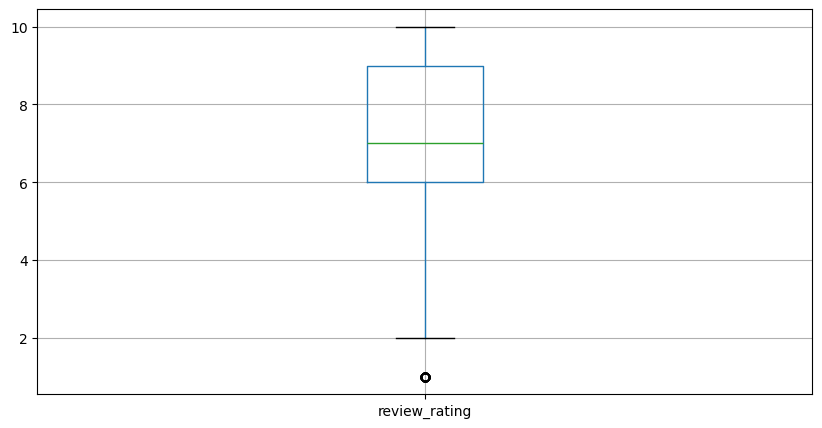

In [19]:
df.boxplot(figsize=(10,5))
plt.show()

In [31]:
df=df[['review_rating','review']]

In [41]:
def sentiment(rating):
    if rating>=7:
        return 'positive'
    elif rating<=4:
        return 'negative'
    else :
        return 'neutral'

In [43]:
df['sentiment']=df['review_rating'].apply(sentiment)

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [55]:
vect=TfidfVectorizer()
x=vect.fit_transform(df['review'])

In [57]:
y=df['sentiment']

In [59]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [61]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [63]:
pre=model.predict(x_test)
print(pre[:10])

['positive' 'positive' 'neutral' 'positive' 'positive' 'positive'
 'positive' 'positive' 'positive' 'neutral']


In [67]:
test_review = ["This movie is amazing"]
test_vector = vect.transform(test_review)
result = model.predict(test_vector)
print(result)

['positive']
